In [3]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# modelA = 'deepseek'
# modelA = 'llama'
modelA = 'qwen'
modelB = modelA
languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            ]

batch_shuffle = 0
centers_list = ['sem']
min_token_length = 3
n_files = 16
batch_size = 100
n_tokens_list = [min_token_length]
avg_flags = [0]
Nbits_list = [0]
match_vars = ['matching']
data_vars = ['sem']
zero_activations_list = [0]
center_A_flags = [0,1]
center_B_flags = [0,1]

[]

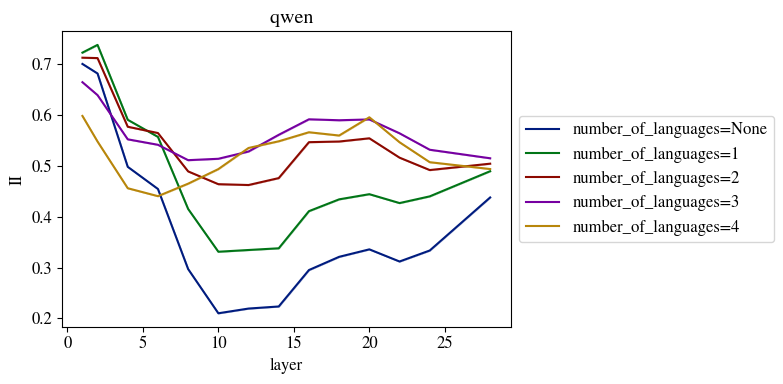

In [10]:
fig,ax = plt.subplots(1,figsize=(8,4))

plot_id = 0
title = ' '

for number_of_languages in [None,1,2,3,4]:
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
      for center_B_id,center_B_flag in enumerate(center_B_flags):
        # if zero_activations == 1 and center_A_flag == 0: continue
        if center_A_flag != center_B_flag: 
          continue
        if number_of_languages is None and center_A_flag == 1: 
          continue
        if center_A_flag == 0 and number_of_languages != None:
          continue
        for data_var_id,data_var in enumerate(data_vars):
          for avg_id,avg_tokens in enumerate(avg_flags):
            for centers_id,centers in enumerate(centers_list):
              for match_id,match_var in enumerate(match_vars):
                for Nbits_id,Nbits in enumerate(Nbits_list):
                  for language_id, language in enumerate(languages):
                    for n_tokens in n_tokens_list:
                      output_folder0 = makefolder(base=f'./results/',
                                                  language=language,
                                                  data_var=data_var,
                                                  modelA=modelA,
                                                  modelB=modelB,
                                                  match_var=match_var,
                                                  n_files=n_files,
                                                  min_token_length=min_token_length,
                                                  )
                      II_folder = makefolder(base=output_folder0,
                                                        centers=centers,
                                                        Nbits=Nbits,
                                                        n_tokens=n_tokens,
                                                        avg_tokens=avg_tokens,
                                                        batch_shuffle=batch_shuffle,
                                                        zero_activations=zero_activations,
                                                        center_A_flag=center_A_flag,
                                                        center_B_flag=center_B_flag,
                                                        number_of_languages=number_of_languages,
                                                        )
                      inf_imb = np.load(II_folder + "II.npy")
                      std = np.load(II_folder + "II_jack_std.npy")

                      layers_A = list(range(1,depths[modelA] + 1))
                      layers_B = list(range(1,depths[modelB] + 1))
                      layers = reduce_list_half_preserve_extremes(layers_A)
                      color = colors[plot_id] 
                      # if 0: 
                      #   color = colors[plot_id]
                      #   linestyle = '-'
                      #   label = f'centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                      # if 1: 
                      #   color = colors[plot_id] 
                      #   if zero_activations:
                      #     label = f'{language}, centers_A | centering_B:{center_B_flag}'
                      #   else:
                      #     label = f'{language}, centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                      label = f'{number_of_languages=}'
                      for II_index in range(1):
                        ax.plot(layers,
                                inf_imb[II_index].diagonal(),
                                label=label,
                                linestyle=_linestyles[II_index],
                                color=color,
                                ) 
                        ax.fill_between(layers,
                                        inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                        inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                        alpha=0.2,
                                        color=color,
                                        )
                      plot_id += 1

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_title(title + f' {modelA}')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.plot()

### Similarities

In [5]:
# layer_A = 1
# layer_B = 1
# method = 'min'
# sim_folder = makefolder(base=output_folder0+f'similarities/',
#                         create_folder=False,
#                         Nbits=Nbits,
#                         n_tokens=n_tokens,
#                         avg_tokens=avg,
#                         batch_shuffle=batch_shuffle,
#                         layer_A=layer_A,
#                         layer_B=layer_B,
#                         )
# II_fn = build_information_imbalance(k=1)

# A_sim = np.load(os.path.join(sim_folder, "sim_A.npy"))
# B_sim = np.load(os.path.join(sim_folder, "sim_B.npy")) 


In [20]:
from collections import deque

languages = ['chinese', 'german', 'italian', 'spanish']
d = deque(languages)

d.rotate(0)  # Rotate right by 1
print(list(d))  # ['spanish', 'chinese', 'german', 'italian']

d.rotate(1)  # Rotate right by 1
print(list(d))  # ['spanish', 'chinese', 'german', 'italian']

d.rotate(1)  # Rotate left by 2
print(list(d))  # ['german', 'italian', 'spanish', 'chinese']

d.rotate(1)  # Rotate left by 2
print(list(d))  # ['german', 'italian', 'spanish', 'chinese']




['chinese', 'german', 'italian', 'spanish']
['spanish', 'chinese', 'german', 'italian']
['italian', 'spanish', 'chinese', 'german']
['german', 'italian', 'spanish', 'chinese']
